# STEREO / SWAVES dynamic spectrum

This notebook plots the combined STEREO-A SWAVES Level-2 product. SWAVES is
a sweep-frequency radio receiver covering **2.6 kHz - 16.025 MHz** in a single
contiguous band.

The relevant CDF variables are:

- `Epoch`: time stamps
- `frequency`: frequency axis in kHz
- `avg_intens_ahead`: STEREO-A combined intensity (use `avg_intens_behind`
  for STEREO-B if needed)

Three loaders are provided: a `fetch_STAswaves` helper that downloads the
Level-2 CDF from SPDF if it is not already on disk (default), a manual
`pycdf` reader for files you already have locally, and an alternative based
on `pyspedas`.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import LogNorm
import matplotlib as mpl
from scipy.ndimage import gaussian_filter

# Use the precise matplotlib epoch (avoids ~10 us offsets in old matplotlib).
mpl.rcParams['date.epoch'] = '1970-01-01T00:00:00'
try:
    mdates.set_epoch('1970-01-01T00:00:00')
except RuntimeError:
    pass

# Unified plotting style for all dynamic spectra notebooks.
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

from astropy.visualization import ImageNormalize, PercentileInterval

## Configuration


In [3]:
mydate = '2024-05-14'
year, month, day = mydate.split('-')

data_dir = './sample_data/swaves'
outputs  = './outputs'
os.makedirs(data_dir, exist_ok=True)
os.makedirs(outputs, exist_ok=True)

## Helper functions


In [4]:
def subtract_background_median(df):
    """
    Subtract a per-channel median background from a dynamic spectrum.

    The function computes the median along the time axis (axis=0) for each
    frequency channel, then subtracts it from every time sample of that
    channel. This is the standard approach for highlighting transient
    emission against a slowly-varying instrumental/sky background.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with shape (n_times, n_freqs). Index is time, columns
        are frequencies.

    Returns
    -------
    pandas.DataFrame
        Same shape as input with the per-channel median removed.
    """
    bkg = np.nanmedian(df.values, axis=0)
    return df - np.tile(bkg, (df.shape[0], 1))


def fetch_STAswaves(year, month, day, rootdir=data_dir):
    """
    Download and load a STEREO-A / SWAVES Level-2 CDF from SPDF.

    The file is fetched only if it is not already cached under `rootdir`.
    After loading, a per-channel mean is subtracted and a light Gaussian
    smoothing (sigma=1) is applied. A percentile-clipped normalisation is
    returned alongside the data so the result is ready to drop into
    pcolormesh.

    Parameters
    ----------
    year, month, day : str
        Date components, zero-padded (e.g. '2024', '05', '14').
    rootdir : str
        Directory to store the downloaded CDF.

    Returns
    -------
    time_ste : np.ndarray of datetime
    freq_ste : np.ndarray, kHz
    smoothed_ste_A : pd.DataFrame
        Background-subtracted, smoothed (freq, time) intensity.
    ste_norm : astropy.visualization.ImageNormalize
        Percentile-clipped normalisation suitable for pcolormesh.
    """
    # NB: pycdf imported lazily so a missing CDF library only matters at use time.
    from spacepy import pycdf

    os.makedirs(rootdir, exist_ok=True)
    fname     = f'stereo_level2_swaves_{year}{month}{day}_v02.cdf'
    file_path = os.path.join(rootdir, fname)

    if not os.path.exists(file_path):
        url = (
            'https://spdf.gsfc.nasa.gov/pub/data/stereo/combined/swaves/'
            f'level2_cdf/{year}/{fname}'
        )
        print(f'Downloading {url}')
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        with open(file_path, 'wb') as f:
            f.write(response.content)
    else:
        print(f'Using cached file: {file_path}')

    cdf_stereo = pycdf.CDF(file_path)
    time_ste = np.array(cdf_stereo.get('Epoch'))
    freq_ste = np.array(cdf_stereo.get('frequency'))
    data_ste_A = np.array(cdf_stereo.get('avg_intens_ahead'))

    # Per-channel mean subtraction (rows = frequency channels after transpose).
    df_ste_A    = pd.DataFrame(data_ste_A.T)
    df_ste_mean = df_ste_A.mean(axis=1)
    data_ste_A  = df_ste_A.sub(df_ste_mean, axis=0)

    smoothed_ste_A = gaussian_filter(data_ste_A, sigma=1)
    ste_norm = ImageNormalize(smoothed_ste_A, interval=PercentileInterval(98))

    return time_ste, freq_ste, smoothed_ste_A, ste_norm

## Load STEREO/SWAVES with `fetch_STAswaves` (default)

The helper checks `data_dir` first; if the file is missing it is downloaded
from the SPDF mirror, otherwise the cached copy is reused.


In [5]:
time_ste, freq_ste, smoothed_ste_A, ste_norm = fetch_STAswaves(year, month, day)

# smoothed_ste_A from the helper has shape (n_freq, n_time); transpose to
# (n_time, n_freq) so we can use time as the DataFrame index.
df_ste = pd.DataFrame(np.asarray(smoothed_ste_A).T,
                      index=time_ste, columns=freq_ste)

print(f'Shape (time, freq): {df_ste.shape}')
print(f'Time range: {time_ste[0]} -> {time_ste[-1]}')
print(f'Freq range: {freq_ste[0]:.2f} kHz - {freq_ste[-1]/1e3:.2f} MHz')

Shape (time, freq): (1440, 367)
Time range: 2024-05-14 00:00:30 -> 2024-05-14 23:59:30
Freq range: 2.61 kHz - 16.02 MHz


## Alternative loader: manual `pycdf` on an existing file

If you already have a SWAVES CDF locally and do not want to touch the network,
load it directly with `pycdf`. Uncomment to use this branch.


In [6]:
# from spacepy import pycdf
#
# swaves_files = sorted(glob.glob(
#     f'{data_dir}/stereo_level2_swaves_{year}{month}{day}*.cdf'
# ))
# print(*swaves_files, sep='\n')
# cdf = pycdf.CDF(swaves_files[0])
#
# time_ste = np.asarray(cdf['Epoch'])
# freq_ste = np.asarray(cdf['frequency'])          # kHz
# data_ste = np.asarray(cdf['avg_intens_ahead'])   # STEREO-A

## Alternative loader: `pyspedas`

Uncomment to use `pyspedas.stereo.waves` instead.


In [7]:
# import pyspedas
# from pytplot import get_data
#
# pyspedas.stereo.waves(trange=[mydate, mydate], probe='a', datatype='l2_avg', no_update=True)
# ts, val, freq_ste = get_data('avg_intens_ahead')
# time_ste = pd.to_datetime(ts, unit='s').to_pydatetime()
# data_ste = val  # shape (n_time, n_freq), units already in kHz for freq_ste

## (Optional) further background removal

`fetch_STAswaves` already subtracts a per-channel mean and applies a light
Gaussian smoothing. If you used one of the alternative loaders above and want
the standard per-channel median subtraction instead, uncomment the cell below.


In [8]:
# df_ste_nobkg = subtract_background_median(df_ste)
# df_ste = df_ste_nobkg

## Plot the dynamic spectrum

`ste_norm` comes from `fetch_STAswaves` and is a `PercentileInterval(98)` norm.

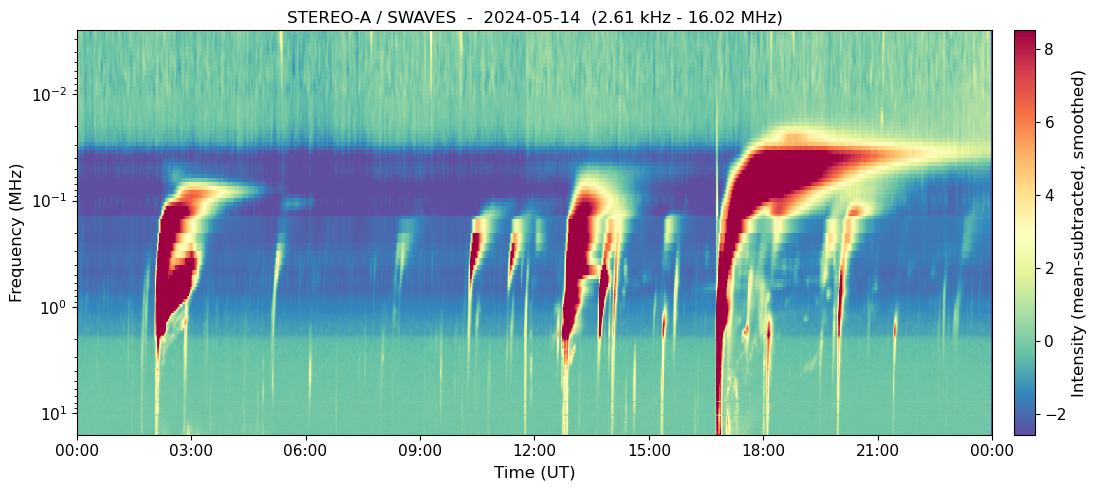

In [9]:
fig = plt.figure(figsize=(12, 5))
ax  = fig.add_subplot(111)
pc  = ax.pcolormesh(
    df_ste.index,
    df_ste.columns / 1e3,         # kHz -> MHz for the y-axis label
    df_ste.values.T,
    norm=ste_norm, cmap='Spectral_r',
)
fig.colorbar(pc, ax=ax, pad=0.02, label='Intensity (mean-subtracted, smoothed)')

ax.set_yscale('log')
ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_title(f'STEREO-A / SWAVES  -  {mydate}'
             f'  ({freq_ste[0]:.2f} kHz - {freq_ste[-1]/1e3:.2f} MHz)')

fig.tight_layout()
fig.savefig(f'{outputs}/swaves_dyspec_{mydate}.png', bbox_inches='tight')
plt.show()